### Imports and settings

In [ ]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from pathlib import Path
import colorcet as cc
import calendar
from scipy import stats
from importlib import reload
import dyndowntools.util as du

In [ ]:
reload(du)

<module 'dyndowntools.util' from '/Users/chris/Projects/dyndowntools/dyndowntools/util.py'>

In [ ]:
datadir = Path().absolute().parent / "evaluation/working"
figdir = Path().absolute().parent / "evaluation/figures"
stationdir = Path().absolute().parent / "evaluation/weatherstationdata/ACIS"
filepattern_ERA5 = 't2m_{agg}_{airport}_1981_2020_{resolution}.csv'
filepattern_ERA5_2 = 'era5_{airport}_Tmean_1981_2020_monthly.csv'
filepattern_station = "{station}_T_max_min_avg_pcpn_sd_swe.csv"

In [ ]:
stations = {
    "ANCHORAGE_TED_STEVENS_INTERNATIONAL_AIRPORT": "ANC_PANC",
    "FAIRBANKS_INTL_AP": "FAI_PAFA",
    "BARROW_AIRPORT": "UTQ_PABR",
    "BETHEL_AIRPORT": "BTH_PABE"
}
startdate = '1981-01-01'
enddate = '2020-12-31'
agg = 'mean'
fullnames = list(stations.keys())
resolutions = ['4km', '12km']
teststation = 'BETHEL_AIRPORT'

In [ ]:
month_abbr = [calendar.month_abbr[ii] for ii in range(1, 13)]
month_initials = [item[0] for item in month_abbr]

### Functions

In [ ]:
def F2C(temp_F):
    return (temp_F - 32.0) * 5.0/9.0

In [ ]:
def get_dataframe_ERA5(station, startdate=startdate, enddate=enddate):
    dfs = {}
    var = f'T2_{agg}'
    for res in resolutions:
        dfs[res] = pd.read_csv(
            datadir / filepattern_ERA5.format(airport=stations[station], agg=agg, resolution=res))
        dfs[res]['Time'] = pd.to_datetime(dfs[res]['Time'])
        dfs[res][var] = dfs[res][var] - 273.15      # K to C
        dfs[res].rename(columns={var: f"{var}_{res}"}, inplace=True)
        # dfs[res].set_index('Time')
    dfs['4km'][f'{var}_12km'] = dfs['12km'][f'{var}_12km']
    return dfs['4km']

def get_dataframe_station(station, startdate=startdate, enddate=enddate):
    stationpth = stationdir / filepattern_station.format(station=station)
    df = du.station2df(stationpth)
    # return df
    if agg=='max':
        df['Tmax_C'] = F2C(df['Tmax_F'].astype(float))
        return df['Tmax_C'].loc[startdate:enddate]
    elif agg=='mean':
        df['Tmean_C'] = F2C(df['Tavg_F'])
        return df['Tmean_C'].loc[startdate:enddate]
    return df.loc[startdate:enddate]

def get_dataframe(station, startdate=startdate, enddate=enddate):
    ERA5df = get_dataframe_ERA5(station, startdate=startdate, enddate=enddate)
    stationdf = get_dataframe_station(station, startdate=startdate, enddate=enddate)
    ERA5df.set_index('Time', inplace=True)
    ERA5df.index = pd.to_datetime(ERA5df.index)
    stationdf.index.name = 'Time'
    stationdf.index = pd.to_datetime(stationdf.index)

    return pd.merge(ERA5df, stationdf,
            how='inner', left_index=True, right_index=True)

In [ ]:
def get_stats(teststation, monthlyDF):
    output = []
    for variable in (f'T{agg}', f'T2_{agg}_4km', f'T2_{agg}_12km', f'T{agg}_C'):
        for mth in range(1, 13):
            X = monthlyDF.query(f'month == {mth}')['year']
            Y = monthlyDF.query(f'month == {mth}')[variable]
            slope, _, r_value, p_value, _ = stats.linregress(X, Y)
            mean = Y.mean()
            output.append({
                "location": stations[teststation][4:],
                'variable': variable,
                'month': mth, 
                'mean_monthly_T': mean, 
                'trend': slope, 
                'p_value': p_value, 
                'r_value':r_value})
    return output

In [ ]:
def get_monthly(dailyDF):
    # dailyDF = dailyDF.loc[startdate:enddate]
    monthly_avg = dailyDF[[f'T2_{agg}_4km', f'T2_{agg}_12km', f'T{agg}_C']].groupby(
        pd.Grouper(freq='M')).mean()
    monthly_avg['year'] = monthly_avg.index.year
    monthly_avg['month'] = monthly_avg.index.month
    return monthly_avg

In [ ]:
def get_name(location):
    name = location.split(' ')[0].title()
    if name == 'Barrow':
        return 'Utqiaġvik'
    else:
        return name

In [ ]:
def add_significance_suffix(p_value):
    if p_value < 0.05:
        return ' (**)'
    elif p_value < 0.1:
        return ' (*)'
    else: return ''

### Single location prototyping

In [ ]:
get_dataframe(teststation)

,T2_mean_4km,T2_mean_12km,Tavg_C
Time,,,
1981-01-01,0.119,0.079,-0.833333
1981-01-02,-8.863,-8.915,-4.166667
1981-01-03,-3.553,-3.559,-4.444444
1981-01-04,-0.394,-0.386,-2.777778
1981-01-05,-1.216,-1.604,-2.222222
...,...,...,...
2020-12-27,-1.615,-1.773,-3.055556
2020-12-28,0.156,-0.579,-0.555556
2020-12-29,-0.273,-0.313,-1.388889


In [ ]:
teststation

'BETHEL_AIRPORT'

In [ ]:
stationpth = stationdir / filepattern_station.format(station=teststation)
df = du.station2df(stationpth)
df

,Tmax_F,Tmin_F,Tavg_F,precip_in,sd_m,swe,year
1951-01-02,12.0,3.0,7.5,0.01,4,-9999,1951
1951-01-03,8.0,2.0,5.0,0.01,4,-9999,1951
1951-01-04,14.0,8.0,11.0,0.00,4,-9999,1951
1951-01-05,32.0,9.0,20.5,0.37,5,-9999,1951
1951-01-06,32.0,27.0,29.5,0.13,8,-9999,1951
...,...,...,...,...,...,...,...
2020-12-27,37.0,16.0,26.5,0.01,-9999,-9999,2020
2020-12-28,37.0,25.0,31.0,0.01,-9999,-9999,2020
2020-12-29,37.0,22.0,29.5,0.00,-9999,-9999,2020
2020-12-30,28.0,12.0,20.0,0.00,-9999,-9999,2020


In [ ]:
compDF = get_dataframe(teststation)
monthly_DF = get_monthly(compDF)
monthly_undownscaled = pd.read_csv(datadir / filepattern_ERA5_2.format(
    airport=stations[teststation][4:]), skiprows=2)
monthly_DF['Tmean'] = monthly_undownscaled['t2m'].values 
monthly_DF

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_70263/2457391200.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()


,T2_mean_4km,T2_mean_12km,Tmean_C,year,month,Tmean
Time,,,,,,
1981-01-31,-6.313000,-6.329065,-6.191756,1981,1,-5.198
1981-02-28,-13.875893,-14.127536,-10.902778,1981,2,-10.301
1981-03-31,-3.934419,-3.968516,-1.424731,1981,3,-0.923
1981-04-30,-3.425200,-2.889567,0.138889,1981,4,0.218
1981-05-31,8.709161,8.905419,8.942652,1981,5,9.469
...,...,...,...,...,...,...
2020-08-31,12.939710,13.169839,13.055556,2020,8,13.280
2020-09-30,7.028133,7.181000,7.407407,2020,9,7.462
2020-10-31,2.076032,2.159710,2.249104,2020,10,2.638


In [ ]:
get_stats(teststation, monthly_DF)

[{'location': 'PABE',
  'variable': 'Tmean',
  'month': 1,
  'mean_monthly_T': -13.279675000000001,
  'trend': -0.0156657598499062,
  'p_value': 0.8329943620590781,
  'r_value': -0.034421989593581205},
 {'location': 'PABE',
  'variable': 'Tmean',
  'month': 2,
  'mean_monthly_T': -10.747375,
  'trend': 0.13512560975609758,
  'p_value': 0.062178408791704415,
  'r_value': 0.29760179062236136},
 {'location': 'PABE',
  'variable': 'Tmean',
  'month': 3,
  'mean_monthly_T': -8.632825,
  'trend': -0.056597091932457794,
  'p_value': 0.29736308390385546,
  'r_value': -0.16894028393573984},
 {'location': 'PABE',
  'variable': 'Tmean',
  'month': 4,
  'mean_monthly_T': -1.5972750000000002,
  'trend': 0.093196904315197,
  'p_value': 0.03118890854509526,
  'r_value': 0.34120306322763105},
 {'location': 'PABE',
  'variable': 'Tmean',
  'month': 5,
  'mean_monthly_T': 6.4243250000000005,
  'trend': 0.049208536585365864,
  'p_value': 0.07362465939882952,
  'r_value': 0.28598400702861404},
 {'location

In [ ]:
output = []
for mth in range(1, 13):
    X = monthly_DF.query(f'month == {mth}')['year']
    Y = monthly_DF.query(f'month == {mth}')[f'T{agg}']
    slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)
    mean = Y.mean()
    output.append((mth, mean, slope, p_value, r_value, std_err))

In [ ]:
mth = 8
X = monthly_DF.query(f'month == {mth}')['year']
Y = monthly_DF.query(f'month == {mth}')[f'T{agg}']
slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)

In [ ]:
slope, intercept, p_value

(0.02762607879924952, -43.11637063789866, 0.10096687074658861)

In [ ]:
cmap = plt.cm.get_cmap('cet_glasbey')
cmap = plt.cm.get_cmap('Set1')

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_3995/1137458020.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('cet_glasbey')
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_3995/1137458020.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1')


In [ ]:
# monthly_DF.index.name = 'Time'
df_forplot = pd.melt(monthly_DF.reset_index(), id_vars=[monthly_DF.index.name, 'year', 'month'], 
        value_vars=['Tmean', 'T2_mean_12km', 'T2_mean_4km', 'Tmean_C'], value_name='meanT', var_name=teststation)

In [ ]:
# palette = sns.color_palette(cc.b_glasbey_category10, n_colors=4)
palette = sns.color_palette("Set2", 10)
viridis_palette = sns.color_palette("viridis", 25)
# viridis_palette = [viridis_palette[ii] for ii in [14, 8, -1]]
# viridis_palette
palette

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 (1.0, 0.8509803921568627, 0.1843137254901961),
 (0.8980392156862745, 0.7686274509803922, 0.5803921568627451),
 (0.7019607843137254, 0.7019607843137254, 0.7019607843137254),
 (0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961)]

In [ ]:
# palette = palette[[0, 1, 2, 7]]
palette[3] = palette[7]
palette = palette[:4]
palette

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.7019607843137254, 0.7019607843137254, 0.7019607843137254)]

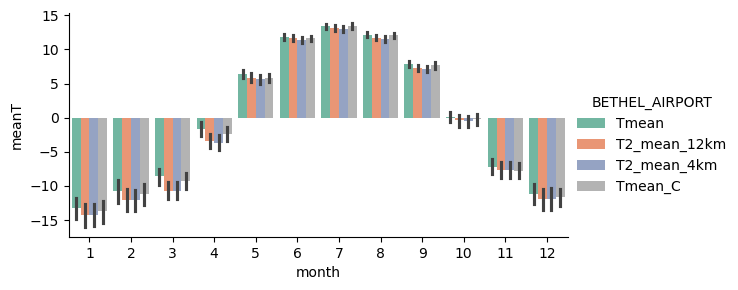

In [ ]:
g = sns.catplot(data=df_forplot, kind="bar", x="month", y="meanT", 
            hue=teststation, palette=palette, width=0.85, height=3, aspect=2)
# g._legend.remove()

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_70263/3433591431.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)


Text(0.5, 1.0, 'BETHEL_AIRPORT')

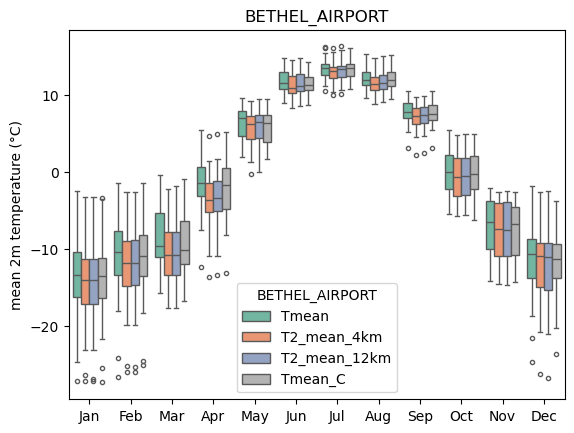

In [ ]:
g = sns.boxplot(data=df_forplot, x="month", y="meanT", 
            hue=teststation, palette=palette, legend=True, fliersize=3)
g.set_xticklabels(month_abbr)
g.set_xlabel('')
g.set_ylabel('mean 2m temperature (°C)')
g.set_title(teststation)

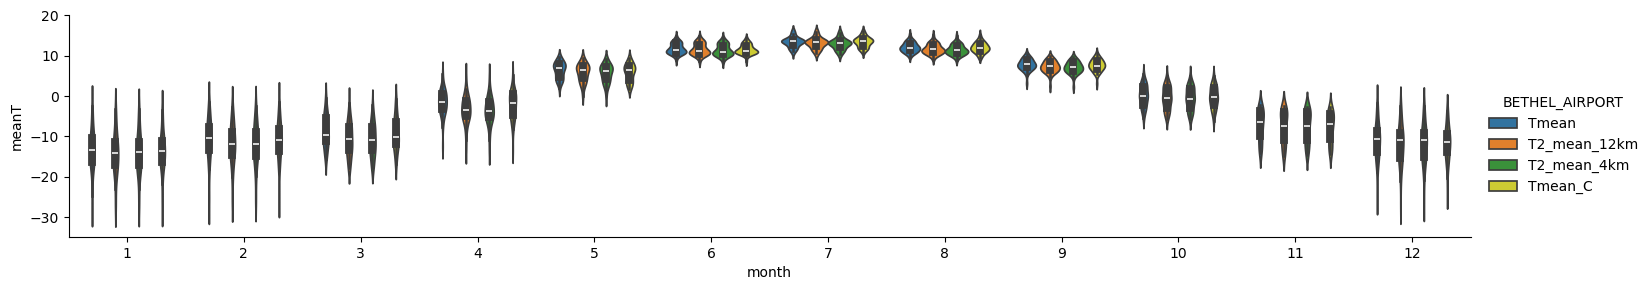

In [ ]:
g = sns.catplot(data=df_forplot, kind="violin", x="month", y="meanT", 
            hue=teststation, palette=palette, height=3, aspect=5)


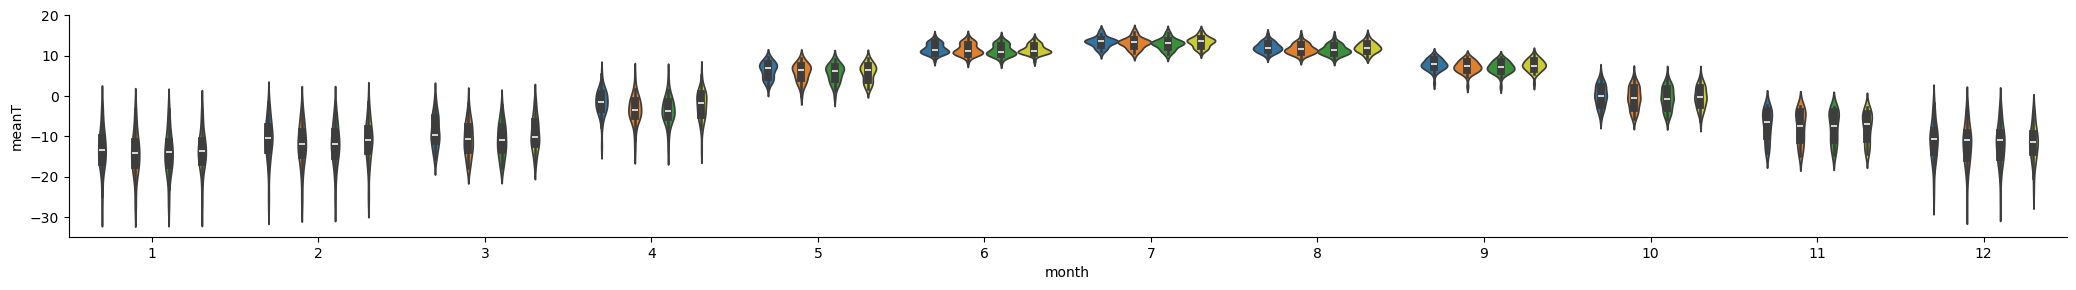

In [ ]:
g = sns.catplot(data=df_forplot, kind="violin", x="month", y="meanT", 
            hue=teststation, palette=palette, height=3, aspect=7)
g._legend.remove()

<Axes: xlabel='Time'>

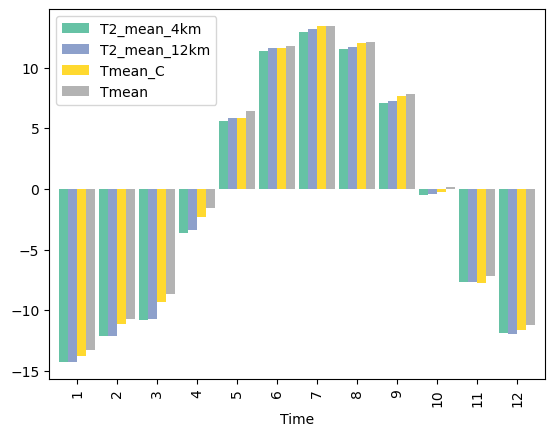

In [ ]:
monthly_DF.drop(columns=['month', 'year']).groupby(monthly_DF.index.month).mean().plot(
    kind='bar', width=0.9, cmap='Set2')

### Make all plots and statistics

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_70263/2457391200.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_70263/53498830.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_70263/2457391200.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_70263/53498830.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_70263/2457391200.py:4: FutureWarnin

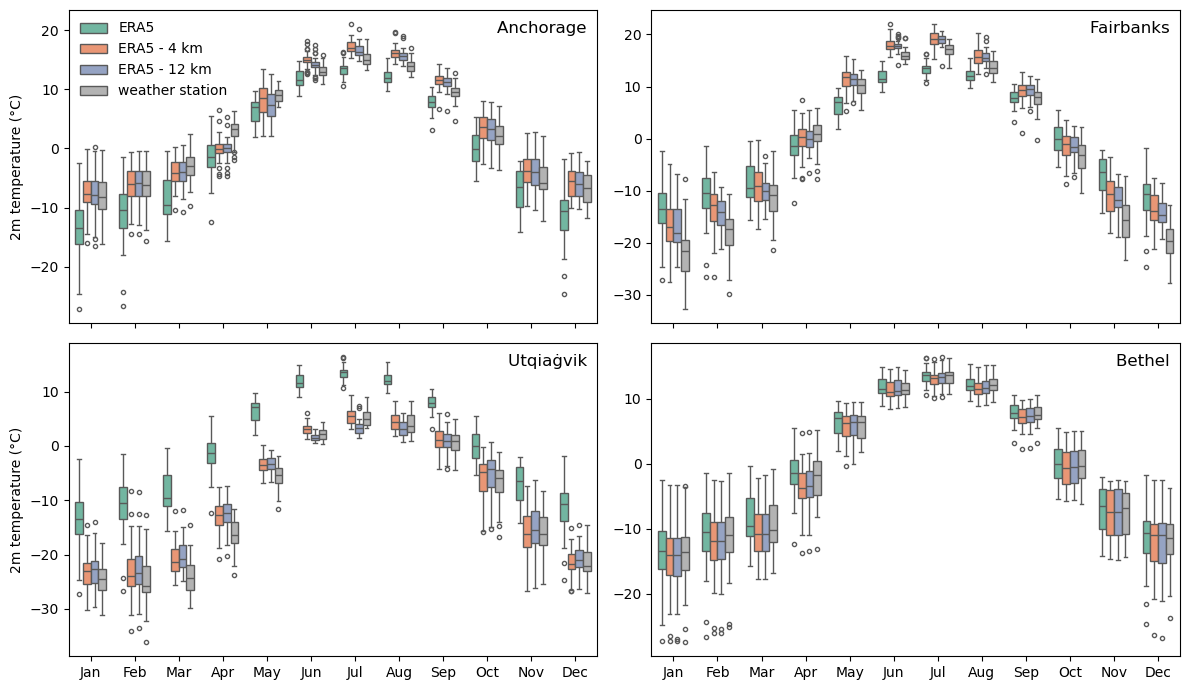

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 7), sharex=True)

results = []
for ii, (ax, station) in enumerate(zip(axes.flatten(), stations)):
    compDF = get_dataframe(station)
    locationname = get_name(station.replace('_', ' '))
    monthly_DF = get_monthly(compDF)
    monthly_undownscaled = pd.read_csv(datadir / filepattern_ERA5_2.format(
    airport=stations[teststation][4:]), skiprows=2)
    monthly_DF['Tmean'] = monthly_undownscaled['t2m'].values 
    monthly_DF.index.name = 'Time'
    # results.extend(get_stats(station, monthly_DF))
    df_forplot = pd.melt(monthly_DF.reset_index(), id_vars=[monthly_DF.index.name, 'year', 'month'], 
        value_vars=['Tmean', 'T2_mean_4km', 'T2_mean_12km', 'Tmean_C'], value_name='meanT', var_name=station)
    g = sns.boxplot(data=df_forplot, x="month", y="meanT", 
            hue=station, palette=palette, width=0.7, fliersize=3, ax=ax)
    ax.get_legend().remove()  
    g.set_xticklabels(month_abbr)
    g.set_xlabel('')
    if ii%2:
        g.set_ylabel('')
    else:
        g.set_ylabel('2m temperature (°C)')
    ax.set_title(locationname + '  ' , loc='right', y=0.9)
handles, _ = ax.get_legend_handles_labels()
labels = ['ERA5', 'ERA5 - 4 km', 'ERA5 - 12 km', 'weather station']
fig.legend(handles, labels, loc='upper left', ncol=1, bbox_to_anchor=(0.06, 0.98), frameon=False)
plt.tight_layout()

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_70263/2457391200.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_70263/2945354256.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_70263/2457391200.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_70263/2945354256.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_70263/2457391200.py:4: FutureWa

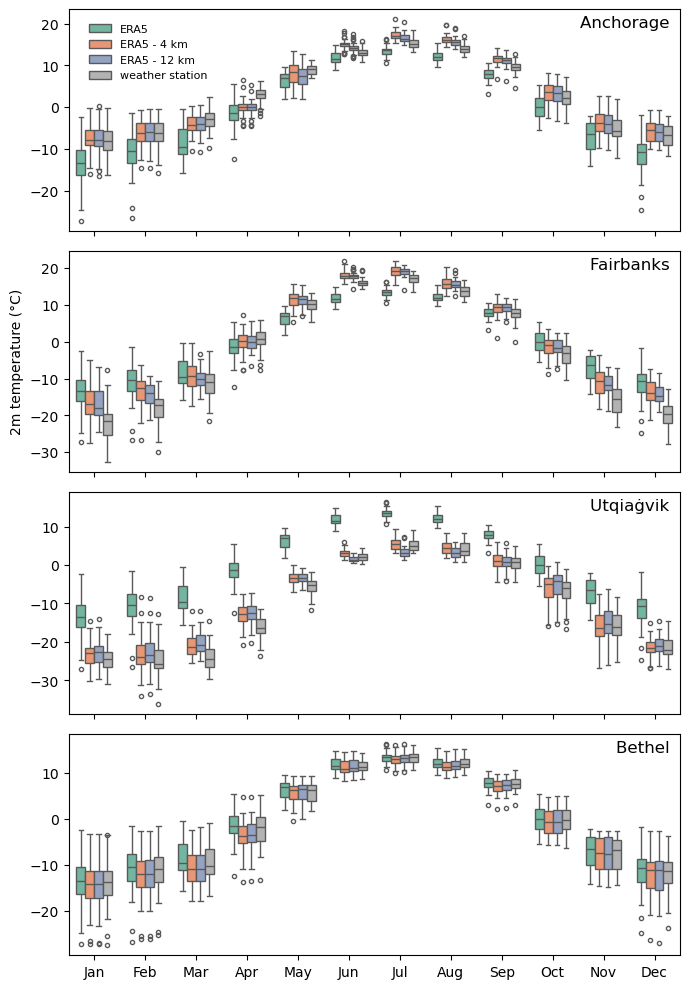

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(7, 10), sharex=True)

results = []
for ii, (ax, station) in enumerate(zip(axes.flatten(), stations)):
    compDF = get_dataframe(station)
    locationname = get_name(station.replace('_', ' '))
    monthly_DF = get_monthly(compDF)
    monthly_undownscaled = pd.read_csv(datadir / filepattern_ERA5_2.format(
    airport=stations[teststation][4:]), skiprows=2)
    monthly_DF['Tmean'] = monthly_undownscaled['t2m'].values 
    monthly_DF.index.name = 'Time'
    # results.extend(get_stats(station, monthly_DF))
    df_forplot = pd.melt(monthly_DF.reset_index(), id_vars=[monthly_DF.index.name, 'year', 'month'], 
        value_vars=['Tmean', 'T2_mean_4km', 'T2_mean_12km', 'Tmean_C'], value_name='meanT', var_name=station)
    g = sns.boxplot(data=df_forplot, x="month", y="meanT", 
            hue=station, palette=palette, width=0.7, fliersize=3, ax=ax)
    ax.get_legend().remove()  
    g.set_xticklabels(month_abbr)
    g.set_xlabel('')
    if not ii==1:
        g.set_ylabel('')
    else:
        g.set_ylabel('2m temperature (°C)')
    # if ii>0:
    #     ax.set_title('  ' + locationname, loc='left', y=0.9)
    # else:
    ax.set_title(locationname + '  ' , loc='right', y=0.88)
handles, _ = ax.get_legend_handles_labels()
labels = ['ERA5', 'ERA5 - 4 km', 'ERA5 - 12 km', 'weather station']
fig.legend(handles, labels, 
           loc='upper left', ncol=1, bbox_to_anchor=(0.12, 0.98), 
           fontsize=8, frameon=False)
plt.tight_layout()

In [ ]:
fn = f"t{agg}_stations_monthly_distribution_box_{startdate}-{enddate}.png"
fig.savefig(figdir / fn, bbox_inches='tight', dpi=300)

In [ ]:
results = []
for station in stations:
    compDF = get_dataframe(station)
    location = stations[station]
    monthly_DF = get_monthly(compDF)
    monthly_undownscaled = pd.read_csv(datadir / filepattern_ERA5_2.format(
        airport=stations[teststation][4:]), skiprows=2)
    monthly_DF['Tmean'] = monthly_undownscaled['t2m'].values 
    monthly_DF.index.name = 'Time'
    results.extend(get_stats(station, monthly_DF))

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_70263/2457391200.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_70263/2457391200.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_70263/2457391200.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_70263/2457391200.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()


In [ ]:
monthly_DF

,T2_mean_4km,T2_mean_12km,Tmean_C,year,month,Tmean
Time,,,,,,
1981-01-31,-6.313000,-6.329065,-6.191756,1981,1,-5.198
1981-02-28,-13.875893,-14.127536,-10.902778,1981,2,-10.301
1981-03-31,-3.934419,-3.968516,-1.424731,1981,3,-0.923
1981-04-30,-3.425200,-2.889567,0.138889,1981,4,0.218
1981-05-31,8.709161,8.905419,8.942652,1981,5,9.469
...,...,...,...,...,...,...
2020-08-31,12.939710,13.169839,13.055556,2020,8,13.280
2020-09-30,7.028133,7.181000,7.407407,2020,9,7.462
2020-10-31,2.076032,2.159710,2.249104,2020,10,2.638


In [ ]:
resultsDF = pd.DataFrame.from_records(results)
resultsDF

,location,variable,month,mean_monthly_T,trend,p_value,r_value
0,PANC,Tmean,1,-13.279675,-0.015666,0.832994,-0.034422
1,PANC,Tmean,2,-10.747375,0.135126,0.062178,0.297602
2,PANC,Tmean,3,-8.632825,-0.056597,0.297363,-0.168940
3,PANC,Tmean,4,-1.597275,0.093197,0.031189,0.341203
4,PANC,Tmean,5,6.424325,0.049209,0.073625,0.285984
...,...,...,...,...,...,...,...
187,PABE,Tmean_C,8,12.072013,0.031467,0.072767,0.286803
188,PABE,Tmean_C,9,7.666667,0.036273,0.073394,0.286204
189,PABE,Tmean_C,10,-0.253584,0.104186,0.002380,0.467039
190,PABE,Tmean_C,11,-7.762269,0.045380,0.363401,0.147602


In [ ]:
tableDF = resultsDF.query('variable != "ERA5-12km"')
tableDF['ID'] = tableDF.location + ': ' + tableDF['variable']
tableDF['strtrend'] = tableDF['trend'].round(2).astype(str) 
tableDF['sigtrend'] = tableDF['strtrend'] + tableDF['p_value'].apply(add_significance_suffix)


In [ ]:
sigtable = tableDF.pivot(index='ID', columns='month', values='sigtrend')
sigtable.columns = [calendar.month_abbr[ii] for ii in sigtable.columns]
sigtable

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
ID,,,,,,,,,,,,
PABE: T2_mean_12km,0.0,0.15 (**),-0.05,0.11 (**),0.06 (*),0.04 (**),0.01,0.03 (*),0.04 (*),0.12 (**),0.07,0.01
PABE: T2_mean_4km,0.0,0.15 (**),-0.05,0.11 (**),0.06 (*),0.04 (**),0.01,0.03 (*),0.04 (*),0.12 (**),0.07,0.01
PABE: Tmean,-0.02,0.14 (*),-0.06,0.09 (**),0.05 (*),0.04 (**),0.01,0.03,0.03 (*),0.11 (**),0.05,-0.01
PABE: Tmean_C,-0.01,0.12 (*),-0.06,0.09 (*),0.06 (**),0.04 (**),0.01,0.03 (*),0.04 (*),0.1 (**),0.05,-0.0
PABR: T2_mean_12km,0.05,0.1,0.1 (**),0.12 (**),0.05 (**),0.0,0.05 (**),0.07 (**),0.12 (**),0.27 (**),0.29 (**),0.09 (**)
PABR: T2_mean_4km,0.05,0.1,0.1 (**),0.12 (**),0.05 (**),0.01,0.03,0.05 (**),0.12 (**),0.26 (**),0.27 (**),0.08 (**)
PABR: Tmean,-0.02,0.14 (*),-0.06,0.09 (**),0.05 (*),0.04 (**),0.01,0.03,0.03 (*),0.11 (**),0.05,-0.01
PABR: Tmean_C,0.08 (*),0.12 (**),0.11 (**),0.12 (**),0.07 (**),0.02,0.05 (**),0.05 (**),0.11 (**),0.23 (**),0.26 (**),0.1 (**)
PAFA: T2_mean_12km,0.04,0.13 (**),0.04,0.09 (**),0.08 (**),0.01,-0.01,0.02,0.03 (*),0.12 (**),0.11 (**),0.02
